**Business problem** 
- Customer segmentation (RFM) and sales trends.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

retail_raw = pd.read_csv(r"C:\Users\ADMIN\Downloads\Online Retail\online_retail_II.csv")
retail_clean = retail_raw.copy()
retail_clean.head()

,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country
0,489434,85048,15CM CHRISTMAS GLASS BALL 20 LIGHTS,12,2009-12-01 07:45:00,6.95,13085.0,United Kingdom
1,489434,79323P,PINK CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom
2,489434,79323W,WHITE CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom
3,489434,22041,"RECORD FRAME 7"" SINGLE SIZE",48,2009-12-01 07:45:00,2.10,13085.0,United Kingdom
4,489434,21232,STRAWBERRY CERAMIC TRINKET BOX,24,2009-12-01 07:45:00,1.25,13085.0,United Kingdom


# Investigation

In [2]:
retail_clean.shape

(1067371, 8)

In [3]:
print(retail_clean.info())
print(retail_clean.isna().sum())
print(retail_clean.duplicated().sum())
print(retail_clean.dtypes)
print(retail_clean.describe())
print(retail_clean['Country'].unique())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1067371 entries, 0 to 1067370
Data columns (total 8 columns):
 #   Column       Non-Null Count    Dtype  
---  ------       --------------    -----  
 0   Invoice      1067371 non-null  object 
 1   StockCode    1067371 non-null  object 
 2   Description  1062989 non-null  object 
 3   Quantity     1067371 non-null  int64  
 4   InvoiceDate  1067371 non-null  object 
 5   Price        1067371 non-null  float64
 6   Customer ID  824364 non-null   float64
 7   Country      1067371 non-null  object 
dtypes: float64(2), int64(1), object(5)
memory usage: 65.1+ MB
None
Invoice             0
StockCode           0
Description      4382
Quantity            0
InvoiceDate         0
Price               0
Customer ID    243007
Country             0
dtype: int64
34335
Invoice         object
StockCode       object
Description     object
Quantity         int64
InvoiceDate     object
Price          float64
Customer ID    float64
Country         object
d

In [4]:
print((retail_clean['Price'] == 0).sum())
print((retail_clean['Price'] < 0).sum())
print(retail_clean[retail_clean['Price'] < 0])
print(retail_clean[retail_clean['Price'] == 0].head(10))

6202
5
        Invoice StockCode      Description  Quantity          InvoiceDate  \
179403  A506401         B  Adjust bad debt         1  2010-04-29 13:36:00   
276274  A516228         B  Adjust bad debt         1  2010-07-19 11:24:00   
403472  A528059         B  Adjust bad debt         1  2010-10-20 12:04:00   
825444  A563186         B  Adjust bad debt         1  2011-08-12 14:51:00   
825445  A563187         B  Adjust bad debt         1  2011-08-12 14:52:00   

           Price  Customer ID         Country  
179403 -53594.36          NaN  United Kingdom  
276274 -44031.79          NaN  United Kingdom  
403472 -38925.87          NaN  United Kingdom  
825444 -11062.06          NaN  United Kingdom  
825445 -11062.06          NaN  United Kingdom  
     Invoice StockCode   Description  Quantity          InvoiceDate  Price  \
263   489464     21733  85123a mixed       -96  2009-12-01 10:52:00    0.0   
283   489463     71477         short      -240  2009-12-01 10:52:00    0.0   
284   48

In [5]:
mask = ~retail_clean['StockCode'].str.match(r'^\d{5}[A-Za-z]?$')
print(retail_clean.loc[mask, 'StockCode'].unique())

['POST' '79323LP' '15056BL' 'D' '79323GR' 'DCGS0058' 'DCGS0068' 'DOT'
 '15056bl' 'M' 'DCGS0004' 'DCGS0076' 'C2' 'BANK CHARGES' 'DCGS0003'
 'TEST001' 'gift_0001_80' 'DCGS0072' 'gift_0001_20' 'DCGS0044' 'TEST002'
 'gift_0001_10' 'gift_0001_50' 'DCGS0066N' 'gift_0001_30' 'PADS' '72024HC'
 'ADJUST' 'gift_0001_40' 'gift_0001_60' 'gift_0001_70' 'gift_0001_90'
 'DCGSSGIRL' 'DCGS0006' 'DCGS0016' 'DCGS0027' 'DCGS0036' 'DCGS0039'
 'DCGS0060' 'DCGS0056' 'DCGS0059' 'GIFT' 'DCGSLBOY' 'm' 'DCGS0053'
 'DCGS0062' 'DCGS0037' 'DCGSSBOY' 'DCGSLGIRL' 'S' 'DCGS0069' 'DCGS0070'
 'DCGS0075' 'B' 'DCGS0041' 'ADJUST2' '47503J ' 'C3' 'SP1002' 'AMAZONFEE'
 'DCGS0055' 'DCGS0074' 'DCGS0057' 'DCGS0073' 'DCGS0071' 'DCGS0066P'
 'DCGS0067' 'CRUK']


In [6]:
desc_counts = retail_clean.groupby('StockCode')['Description'].nunique()
multi = desc_counts[desc_counts > 1]
print(len(multi))
print(multi.sort_values(ascending=False).head(10))

1232
StockCode
20713     9
22423     7
21181     7
23084     7
22734     7
22719     6
85175     6
47566B    6
21830     6
85172     5
Name: Description, dtype: int64


In [7]:
print(retail_clean[retail_clean['StockCode'] == '20713']['Description'].value_counts())

Description
JUMBO BAG OWLS                  1372
missing                            1
wrongly marked. 23343 in box       1
wrongly coded-23343                1
found                              1
Found                              1
wrongly marked 23343               1
Marked as 23343                    1
wrongly coded 23343                1
Name: count, dtype: int64


In [8]:
print(retail_clean[retail_clean['StockCode'] == '22423']['Description'].value_counts())

Description
REGENCY CAKESTAND 3 TIER    4412
damaged                        3
smashed                        2
faulty                         2
damages                        2
broken, uneven bottom          1
wonky bottom/broken            1
Name: count, dtype: int64


In [9]:
rem_nulls = retail_clean['Description'].dropna()
mask = rem_nulls != rem_nulls.str.upper()
print(mask.sum())
print(rem_nulls[mask].value_counts().head(20))

5967
Description
Manual                                 1426
BAG 250g SWIRLY MARBLES                 598
BAG 125g SWIRLY MARBLES                 596
POLYESTER FILLER PAD 40x40cm            398
POLYESTER FILLER PAD 45x45cm            372
3 TRADITIONAl BISCUIT CUTTERS  SET      268
BAG 500g SWIRLY MARBLES                 240
FRENCH BLUE METAL DOOR SIGN No          186
Discount                                177
check                                   162
Bank Charges                             96
damages                                  84
damaged                                  81
ESSENTIAL BALM 3.5g TIN IN ENVELOPE      80
Next Day Carriage                        80
POLYESTER FILLER PAD 45x30cm             65
POLYESTER FILLER PAD 65CMx65CM           52
POLYESTER FILLER PAD 30CMx30CM           52
FRENCH BLUE METAL DOOR SIGN, No          48
NUMBER TILE COTTAGE GARDEN No            42
Name: count, dtype: int64


In [10]:
retail_clean['Des_Std'] = retail_clean['Description'].str.strip().str.upper()
retail_clean['Des_Std'] = retail_clean['Des_Std'].str.replace(r'\s+', ' ', regex=True)

desc_counts = retail_clean.groupby('StockCode')['Des_Std'].nunique()
multi = desc_counts[desc_counts > 1]
print(len(multi))
print(multi.sort_values(ascending=False).head(10))

1210
StockCode
20713     8
22423     7
22734     7
23084     7
85175     6
21830     6
47566B    6
21181     6
22719     6
22502     5
Name: Des_Std, dtype: int64


In [11]:
pair_counts = retail_clean.groupby(['StockCode', 'Des_Std']).size()
frequent = pair_counts[pair_counts >= 10]
per_code = frequent.groupby('StockCode').size()
real_variants = per_code[per_code > 1]
print(len(real_variants))
print(real_variants.sort_values(ascending=False).head(10))

375
StockCode
20685     4
22785     3
84997a    3
22345     3
22346     3
22333     3
21523     3
21524     3
22356     3
21955     3
dtype: int64


In [12]:
print(retail_clean[retail_clean['StockCode'] == '20685']['Des_Std'].value_counts())

Des_Std
DOORMAT RED RETROSPOT      950
DOOR MAT RED SPOT          417
RED SPOTTY COIR DOORMAT    210
DOORMAT RED SPOT           208
Name: count, dtype: int64


In [13]:
dups = retail_clean[retail_clean.duplicated(keep=False)]
print(dups.sort_values(['Invoice', 'StockCode']).head(10))

    Invoice StockCode                       Description  Quantity  \
379  489517     21491   SET OF THREE VINTAGE GIFT WRAPS         1   
391  489517     21491   SET OF THREE VINTAGE GIFT WRAPS         1   
365  489517     21821  GLITTER STAR GARLAND WITH BELLS          1   
386  489517     21821  GLITTER STAR GARLAND WITH BELLS          1   
363  489517     21912          VINTAGE SNAKES & LADDERS         1   
371  489517     21912          VINTAGE SNAKES & LADDERS         1   
394  489517     21912          VINTAGE SNAKES & LADDERS         1   
362  489517     21913    VINTAGE SEASIDE JIGSAW PUZZLES         1   
385  489517     21913    VINTAGE SEASIDE JIGSAW PUZZLES         1   
368  489517     22130  PARTY CONE CHRISTMAS DECORATION          6   

             InvoiceDate  Price  Customer ID         Country  \
379  2009-12-01 11:34:00   1.95      16329.0  United Kingdom   
391  2009-12-01 11:34:00   1.95      16329.0  United Kingdom   
365  2009-12-01 11:34:00   3.75      16329.0  Un

In [14]:
dups2 = retail_clean[retail_clean.duplicated()]
print((dups2['Quantity'] * dups2['Price']).sum())

431716.87


In [15]:
print((retail_clean['Quantity'] * retail_clean['Price']).sum())

19287250.568


In [16]:
print(retail_clean['Quantity'].nlargest(10))
print(retail_clean['Quantity'].nsmallest(10))

1065882    80995
587080     74215
90857      19152
127166     12960
127168     12960
127169     12744
1027583    12540
127167     12480
192197     10200
135027     10000
Name: Quantity, dtype: int64
1065883   -80995
587085    -74215
303996     -9600
750990     -9600
750991     -9600
507225     -9360
529729     -9360
156488     -9200
750989     -9058
194372     -9000
Name: Quantity, dtype: int64


In [17]:
print(retail_clean.loc[[1065882, 1065883, 587080, 587085]])

         Invoice StockCode                     Description  Quantity  \
1065882   581483     23843     PAPER CRAFT , LITTLE BIRDIE     80995   
1065883  C581484     23843     PAPER CRAFT , LITTLE BIRDIE    -80995   
587080    541431     23166  MEDIUM CERAMIC TOP STORAGE JAR     74215   
587085   C541433     23166  MEDIUM CERAMIC TOP STORAGE JAR    -74215   

                 InvoiceDate  Price  Customer ID         Country  \
1065882  2011-12-09 09:15:00   2.08      16446.0  United Kingdom   
1065883  2011-12-09 09:27:00   2.08      16446.0  United Kingdom   
587080   2011-01-18 10:01:00   1.04      12346.0  United Kingdom   
587085   2011-01-18 10:17:00   1.04      12346.0  United Kingdom   

                                Des_Std  
1065882     PAPER CRAFT , LITTLE BIRDIE  
1065883     PAPER CRAFT , LITTLE BIRDIE  
587080   MEDIUM CERAMIC TOP STORAGE JAR  
587085   MEDIUM CERAMIC TOP STORAGE JAR  


In [18]:
print(retail_clean.nlargest(10, 'Price')[['Invoice', 'StockCode', 'Description', 'Quantity', 'Price']])

         Invoice     StockCode   Description  Quantity     Price
748142   C556445             M        Manual        -1  38970.00
241824   C512770             M        Manual        -1  25111.09
241827    512771             M        Manual         1  25111.09
320581   C520667  BANK CHARGES  Bank Charges        -1  18910.69
1050063  C580605     AMAZONFEE    AMAZON FEE        -1  17836.46
569163   C540117     AMAZONFEE    AMAZON FEE        -1  16888.02
569164   C540118     AMAZONFEE    AMAZON FEE        -1  16453.71
517953   C537630     AMAZONFEE    AMAZON FEE        -1  13541.33
517955    537632     AMAZONFEE    AMAZON FEE         1  13541.33
519294   C537651     AMAZONFEE    AMAZON FEE        -1  13541.33


In [19]:
mask = ~retail_clean['StockCode'].str.match(r'^\d{5}[A-Za-z]?$')
products = retail_clean[~mask]
print(products.nlargest(10, 'Price')[['Invoice', 'StockCode', 'Description', 'Quantity', 'Price']])

       Invoice StockCode                     Description  Quantity    Price
192196  507637     84016      FLAG OF ST GEORGE CAR FLAG         1  1157.15
136403  502451     84016      FLAG OF ST GEORGE CAR FLAG         1   867.79
748132  556444     22502  PICNIC BASKET WICKER 60 PIECES        60   649.50
748143  556446     22502  PICNIC BASKET WICKER 60 PIECES         1   649.50
180997  506571     84016      FLAG OF ST GEORGE CAR FLAG         1   408.40
268525  515349     22656    VINTAGE BLUE KITCHEN CABINET         1   295.00
268526  515349     22655     VINTAGE RED KITCHEN CABINET         1   295.00
268766  515403     22655     VINTAGE RED KITCHEN CABINET         1   295.00
270553  515602     22656    VINTAGE BLUE KITCHEN CABINET         1   295.00
272236  515811     22656    VINTAGE BLUE KITCHEN CABINET         1   295.00


In [20]:
print(products[products['StockCode'] == '84016']['Price'].describe())

count      78.000000
mean       42.633974
std       172.484339
min         0.000000
25%         0.420000
50%         0.420000
75%         0.420000
max      1157.150000
Name: Price, dtype: float64


In [21]:
print(retail_clean['Country'].value_counts().tail(10))

Country
Brazil                94
Thailand              76
Korea                 63
European Community    61
Lebanon               58
West Indies           54
Bermuda               34
Nigeria               32
Czech Republic        30
Saudi Arabia          10
Name: count, dtype: int64


# Data Investigation Findings

**Dataset:** Online Retail II (UCI), 1,067,371 rows, 8 columns
**Period:** Dec 2009 to Dec 2011 (UK online retailer)

## 1. Data Types
- `InvoiceDate` is stored as text (object). Convert to datetime.
- `Customer ID` is float and has a space in its name. Rename to `CustomerID` and convert to integer.

## 2. Missing Values
| Column | Missing | Decision |
|---|---|---|
| Description | 4,382 | Fill from the StockCode's main name, else mark "Unknown" |
| Customer ID | 243,007 | Drop for RFM only. Keep for sales analysis |

## 3. Duplicates
- 34,335 exact duplicate rows (all columns identical).
- Value: £431,717, about 2.2% of total sales (£19,287,251).
- **Decision:** drop. Assumption: a few may be real repeat scans, but no unique ID exists to prove it.

## 4. Invalid Prices
- 5 negative prices: all "Adjust bad debt" (StockCode B). **Remove.**
- 6,202 zero prices: stock write-offs and free items, no Customer ID. **Remove.**
- Price errors: StockCode 84016 (car flag) has a normal price of £0.42, but some rows are £408.40 to £1,157.15. **Fix or remove.**

## 4b. Non-Product StockCodes (remove from sales analysis)
- Postage: POST, DOT
- Manual and adjustments: M, m, ADJUST, ADJUST2, B
- Fees: BANK CHARGES, AMAZONFEE, CRUK
- Other: D (discount), S (samples), C2, C3 (carriage), PADS, TEST001, TEST002, GIFT, gift_0001_*
- These also explain the largest price outliers (£13,000 to £39,000).

## 5. Quantity Outliers
- Negative quantities are mostly returns (Invoice starts with "C"). **Separate, do not delete.**
- Cancelled order pairs (same customer, product, price, quantity, minutes apart):
  - 581483 (+80,995) and C581484 (-80,995), customer 16446
  - 541431 (+74,215) and C541433 (-74,215), customer 12346
  - **Decision:** remove both rows of each pair.
- Other large quantities (12,000 to 19,000) are probably real wholesale orders. **Keep.**

## 6. StockCode Inconsistencies
- Case differences: `15056bl` vs `15056BL`, `m` vs `M`.
- Trailing space: `47503J `.
- **Decision:** uppercase and strip.

## 7. Description Issues
- 1,232 StockCodes have more than one Description (1,210 after standardizing case and spaces).
- Most are junk staff notes (damaged, found, wrongly coded), not product names.
- 375 StockCodes have 2 or more real name variations that each appear 10 or more times.
  - Example, StockCode 20685: DOORMAT RED RETROSPOT (950), DOOR MAT RED SPOT (417), RED SPOTTY COIR DOORMAT (210), DOORMAT RED SPOT (208).
- Typos and punctuation: `TRADITIONAl`, double spaces, `SIGN No` vs `SIGN, No`.
- **Decision:** use the most common name per StockCode. Use fuzzy matching for the leftovers.

## 8. Country
- 43 unique values, no spelling errors.
- "Unspecified" and "European Community" (61 rows) are valid labels. **Keep.**



# Data Cleaning

In [22]:
retail_clean.columns = (retail_clean.columns
    .str.strip()
    .str.replace(' ', '')
    .str.replace(r'(?<=[a-z])(?=[A-Z])', '_', regex=True))

In [23]:
retail_clean = retail_clean.rename(columns={'Des_Std': 'Description_Std'})

In [24]:
retail_clean['Invoice_Date'] = pd.to_datetime(retail_clean['Invoice_Date'])

In [25]:
retail_clean['Stock_Code'] = retail_clean['Stock_Code'].str.strip().str.upper()

In [26]:
retail_clean = retail_clean.drop_duplicates()

In [27]:
non_product = ['POST', 'DOT', 'M', 'D', 'S', 'B', 'C2', 'C3', 'PADS',
               'BANK CHARGES', 'AMAZONFEE', 'CRUK', 'ADJUST', 'ADJUST2',
               'TEST001', 'TEST002', 'GIFT']
mask_list = retail_clean['Stock_Code'].isin(non_product)
print(mask_list.sum())

mask_gift =retail_clean['Stock_Code'].str.startswith('GIFT_0001')
print(mask_gift.sum())

5720
100


In [28]:
remove_mask = mask_list | mask_gift
retail_clean = retail_clean[~remove_mask]

In [29]:
mask_p = retail_clean['Price'] == 0 
retail_clean = retail_clean[~mask_p]

In [30]:
cancelled_orders = ['581483', 'C581484', '541431', 'C541433']
mask_list2 = retail_clean['Invoice'].isin(cancelled_orders)
retail_clean = retail_clean[~mask_list2]

In [31]:
flag = retail_clean[retail_clean['Stock_Code'] == '84016']
print(len(flag))
print((flag['Price'] > 1).sum())

67
12


In [32]:
mask_price = (retail_clean['Stock_Code'] == '84016') & (retail_clean['Price'] > 1)
retail_clean = retail_clean[~mask_price]

In [33]:
retail_clean.shape

(1021238, 9)

In [34]:
retail_clean['Description_Std'].isna().sum()
# Missing Description: 0 after removing zero-price and non-product rows.

np.int64(0)

In [35]:
counts = retail_clean['Description_Std'].value_counts()
rare = counts[counts <= 5]
print(len(rare))
print(rare.head(30))

584
Description_Std
LARGE GLASS SUNDAE DISH CLEAR          5
LIGHT DECORATION BATTERY OPERATED      5
PAPER LANTERN 9 POINT HOLLY STAR 23    5
NUMBER TILE VINTAGE FONT, NO           5
AMBER BERTIE MOBILE PHONE CHARM        5
SMALL FOLKART CHRISTMAS TREE DEC       5
MINI HAND WARMER BABUSHKA DESIGN       5
PEARL & SHELL 42"NECKL. IVORY          5
BUNDLE OF 3 RETRO EXERCISE BOOKS       5
MISELTOE HEART WREATH                  5
RABBIT EASTER DECORATION               5
SET 10 CARDS XMAS CHOIR 17068          5
BLACK GLASS TV DOUBLE P/FRAME 15X10    5
CERAMIC HEART CAKE MONEY BANK          5
PURPLE CRYSTAL DROP EARRINGS           5
RIBBON REEL, MAKING SNOWMEN            5
CHILDRENS SPACEBOY MUG                 5
PINK/WHITE GLASS DEMI CHOKER           5
FAIRY CAKES PHOTO FRAME                5
PINK ROSE PICNIC RUG                   5
CROCHET LILAC/RED BEAR KEYRING         5
SCULPTED ROUND IVORY CANDLE            5
HEART MEASURING SPOONS LARGE           5
SEAGRASS S/2 CORNER LAUNDRY          

In [36]:
checking = retail_clean['Description_Std'].str.contains('DAMAGE|BROKEN|FOUND|CHECK|LOST|SMASHED|WRONG')
print(checking.sum())
print(retail_clean[checking]['Description_Std'].value_counts())

701
Description_Std
BROWN CHECK CAT DOORSTOP              457
SUNSET CHECK HAMMOCK                  113
PAIR PADDED HANGERS PINK CHECK         97
MULTICOLOUR CRUSOE CHECK LAMPSHADE     17
BLUE CHECK BAG W HANDLE 34X20CM        11
BLUE CRUSOE CHECK LAMPSHADE             6
Name: count, dtype: int64


In [37]:
checking2 = retail_clean['Description_Std'].str.contains('DAMAGE|BROKEN|FOUND|LOST|SMASHED|WRONG')
print(checking2.sum())
print(retail_clean[checking2]['Description_Std'].value_counts())

0
Series([], Name: count, dtype: int64)


In [38]:
# 1. Recount name variations
pair_counts = retail_clean.groupby(['Stock_Code', 'Description_Std']).size()
frequent = pair_counts[pair_counts >= 10]
per_code = frequent.groupby('Stock_Code').size()
real_variants = per_code[per_code > 1]
print(len(real_variants))
print(real_variants.sort_values(ascending=False).head(10))

# 2. Extra junk check: rare names next to a much more common name
pair_counts_df = pair_counts.reset_index(name='n')
main_n = pair_counts_df.groupby('Stock_Code')['n'].transform('max')
suspects = pair_counts_df[(pair_counts_df['n'] <= 2) & (main_n >= 50)]
print(len(suspects))
print(suspects.sort_values('n').head(30))

364
Stock_Code
20685     4
22384     3
84997B    3
22197     3
21955     3
84509C    3
22333     3
22345     3
22346     3
21523     3
dtype: int64
92
     Stock_Code                      Description_Std  n
160      17107D    FLOWER FAIRY 5 SUMMER DRAW LINERS  1
2286      22772   DRAWER KNOB ACRYLIC EDWARDIAN PINK  1
2288      22773  DRAWER KNOB ACRYLIC EDWARDIAN GREEN  1
2291      22775  DRAWERKNOB ACRYLIC EDWARDIAN PURPLE  1
2296      22777                 GLASS BELL JAR LARGE  1
2298      22778                 GLASS BELL JAR SMALL  1
2355      22829            BROCANTE SHELF WITH HOOKS  1
2378      22843     BISCUIT TIN, MINT,IVORY, VINTAGE  1
2444      22882          NUMBER TILE VINTAGE FONT, 3  1
2512      22937       BAKING MOULD CUPCAKE CHOCOLATE  1
2537      22954                HEN PARTY BANNER TAPE  1
2543      22959         WRAPPING PAPER, XMAS VILLAGE  1
2631      23035               DOORKNOB CERAMIC IVORY  1
2714      23106                ZINC PLANT POT HOLDER  1
2746     

In [39]:
retail_clean['Description_Clean'] = (
    retail_clean.groupby('Stock_Code')['Description_Std']
    .transform(lambda x: x.mode()[0])
)
print(retail_clean['Description_Clean'].nunique())
print(retail_clean['Stock_Code'].nunique())

4697
4737


In [40]:
x = retail_clean.groupby('Description_Clean')['Stock_Code'].nunique()
mask = x[x > 1]
print(mask)

Description_Clean
ACRYLIC JEWEL SNOWFLAKE,BLUE        2
BATHROOM METAL SIGN                 2
BLACK SILOUETTE CANDLE PLATE        2
BLUE FLOCK GLASS CANDLEHOLDER       2
CHERRY BLOSSOM DECORATIVE FLASK     2
COLOURING PENCILS BROWN TUBE        3
COLUMBIAN CANDLE RECTANGLE          2
COLUMBIAN CANDLE ROUND              4
COLUMBIAN CUBE CANDLE               2
EAU DE NILE JEWELLED PHOTOFRAME     2
FRENCH FLORAL CUSHION COVER         2
FRENCH LATTICE CUSHION COVER        2
FRENCH PAISLEY CUSHION COVER        2
FROSTED WHITE BASE                  2
GINGHAM HEART DECORATION            2
HEART T-LIGHT HOLDER                2
HOME SWEET HOME BLACKBOARD          2
METAL SIGN,CUPCAKE SINGLE HOOK      3
MODERN CHRISTMAS TREE CANDLE        3
PAPER LANTERN 9 POINT SNOW STAR     2
PASTEL BLUE PHOTO ALBUM             2
PASTEL PINK PHOTO ALBUM             2
PINK FAIRY CAKE CUSHION COVER       2
PINK FLOCK GLASS CANDLEHOLDER       2
PINK FLOWERS RABBIT EASTER          2
PINK JEWELLED PHOTO FRAME       

In [41]:
from rapidfuzz import fuzz

In [42]:
mask_changed = retail_clean['Description_Std'] != retail_clean['Description_Clean']
changed = retail_clean[mask_changed][['Stock_Code', 'Description_Std', 'Description_Clean']]
changed = changed.drop_duplicates()
print(changed.shape)
print(changed.head())

(648, 3)
   Stock_Code                     Description_Std  \
7       21523  FANCY FONT HOME SWEET HOME DOORMAT   
8       22350                            CAT BOWL   
9       22349      DOG BOWL , CHASING BALL DESIGN   
10      22195        HEART MEASURING SPOONS LARGE   
11      22353   LUNCHBOX WITH CUTLERY FAIRY CAKES   

                     Description_Clean  
7   DOORMAT FANCY FONT HOME SWEET HOME  
8                 ILLUSTRATED CAT BOWL  
9         DOG BOWL CHASING BALL DESIGN  
10        LARGE HEART MEASURING SPOONS  
11  LUNCH BOX WITH CUTLERY FAIRY CAKES  


In [43]:
changed['ratio_score'] = changed.apply(
    lambda row: fuzz.ratio(row['Description_Std'], row['Description_Clean']),
    axis=1
)


In [44]:
changed['token_score'] = changed.apply(
    lambda row: fuzz.token_sort_ratio(row['Description_Std'], row['Description_Clean']),
    axis=1
)

In [45]:
changed.head()

,Stock_Code,Description_Std,Description_Clean,ratio_score,token_score
7,21523,FANCY FONT HOME SWEET HOME DOORMAT,DOORMAT FANCY FONT HOME SWEET HOME,76.470588,100.000000
8,22350,CAT BOWL,ILLUSTRATED CAT BOWL,57.142857,57.142857
9,22349,"DOG BOWL , CHASING BALL DESIGN",DOG BOWL CHASING BALL DESIGN,96.551724,96.551724
10,22195,HEART MEASURING SPOONS LARGE,LARGE HEART MEASURING SPOONS,78.571429,100.000000
11,22353,LUNCHBOX WITH CUTLERY FAIRY CAKES,LUNCH BOX WITH CUTLERY FAIRY CAKES,98.507463,89.552239


In [46]:
changed['best_score'] = changed[['ratio_score', 'token_score']].max(axis=1)

In [47]:
changed[changed['best_score'] < 70]

,Stock_Code,Description_Std,Description_Clean,ratio_score,token_score,best_score
8,22350,CAT BOWL,ILLUSTRATED CAT BOWL,57.142857,57.142857,57.142857
76,85014B,RED/WHITE DOTS RUFFLED UMBRELLA,RED RETROSPOT UMBRELLA,56.603774,56.603774,56.603774
526,21495,SKULLS WRAP,SKULLS AND CROSSBONES WRAP,59.459459,59.459459,59.459459
757,21786,RAIN HAT WITH RED SPOTS,POLKADOT RAIN HAT,40.000000,50.000000,50.000000
2801,84509C,DOTTY PLACEMATS,SET OF 4 POLKADOT PLACEMATS,61.904762,52.380952,61.904762
4215,21880,RED AND WHITE SPOT TAPE,RED RETROSPOT TAPE,68.292683,63.414634,68.292683
6359,72750A,"F.FAIRY S/3 CANDLE/GLASS,LILY/VALLY",FLOWER FAIRY SET OF 3 LILY CANDLES,49.275362,46.376812,49.275362
12848,84918,CREAM C/COVER W YELLOW/GREEN FLOWER,CREAM CUSHION COVER WITH FLOWERS,62.686567,59.701493,62.686567
21286,84919,L BLUE C/COVER W PINK/YELLOW FLOWER,BLUE CUSHION COVER WITH FLOWER,64.615385,58.461538,64.615385
47592,22175,PINK OWL DECORATION,PINK OWL SOFT TOY,66.666667,44.444444,66.666667


In [48]:
print(retail_clean[retail_clean['Stock_Code'] == '22432']['Description_Std'].value_counts())
print(retail_clean[retail_clean['Stock_Code'] == '22433']['Description_Std'].value_counts())

Description_Std
WATERING CAN PINK BUNNY        517
WATERING CAN GREEN DINOSAUR      6
Name: count, dtype: int64
Description_Std
WATERING CAN GREEN DINOSAUR    424
WATERING CAN PINK BUNNY          5
Name: count, dtype: int64


In [49]:
print(retail_clean[retail_clean['Stock_Code'] == '22829']['Description_Std'].value_counts())
print(retail_clean[retail_clean['Stock_Code'] == '22832']['Description_Std'].value_counts())

Description_Std
SWEETHEART WIRE WALL TIDY    119
BROCANTE SHELF WITH HOOKS      1
Name: count, dtype: int64
Description_Std
BROCANTE SHELF WITH HOOKS    87
SWEETHEART WIRE WALL TIDY     3
Name: count, dtype: int64


In [50]:
mask_c = retail_clean['Invoice'].str.startswith('C')
returns = retail_clean[mask_c]
sales = retail_clean[~mask_c]
print(returns.shape)
print(sales.shape)
print(returns.shape[0] + sales.shape[0] == retail_clean.shape[0])

(17911, 10)
(1003327, 10)
True


In [51]:
sales['Customer_ID'].isna().sum()

np.int64(226750)

In [52]:
rfm_data = sales.dropna(subset= ['Customer_ID'])
rfm_data['Customer_ID'] = rfm_data['Customer_ID'].astype(int)
rfm_data.shape

C:\Users\ADMIN\AppData\Local\Temp\ipykernel_5116\2280307209.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  rfm_data['Customer_ID'] = rfm_data['Customer_ID'].astype(int)


(776577, 10)

In [53]:
rfm_data = rfm_data.drop(columns=['Description_Std'])

In [54]:
rfm_data.columns

Index(['Invoice', 'Stock_Code', 'Description', 'Quantity', 'Invoice_Date',
       'Price', 'Customer_ID', 'Country', 'Description_Clean'],
      dtype='object')

In [55]:
rfm_data.to_csv('rfm_data.csv', index=False)

## Data Cleaning Summary

**Dataset:** Online Retail II (UCI), 1,067,371 rows → 1,021,238 after cleaning

1. Converted `Invoice_Date` to datetime; standardized column names (`Customer_ID`, `Stock_Code`)
2. Standardized `Stock_Code` (uppercase, stripped)
3. Dropped 34,335 exact duplicate rows
4. Removed 5,820 non-product codes (POST, M, fees, gift vouchers, etc.)
5. Removed 5,962 zero/negative-price rows (stock write-offs, no real sale)
6. Removed 2 cancelled-order pairs with matching huge quantities (±80,995, ±74,215)
7. Removed 12 mispriced rows for StockCode 84016 (price entry errors)
8. Missing `Description` fully resolved (0 remaining after prior drops)
9. Merged inconsistent product names per StockCode using majority-vote (`mode()`), validated with fuzzy matching (RapidFuzz) — 648 names changed, 57 low-score cases manually reviewed and confirmed safe
10. Split data into `sales` (1,003,327 rows) and `returns` (17,911 rows) by Invoice prefix "C"
11. Built `rfm_data` (776,577 rows): sales only, with valid CustomerID, ready for RFM analysis

**Known limitations:** 34 product names shared across 2–4 StockCodes (kept separate); ~2.2% of raw data removed as duplicates.

# Analysis

In [56]:
print(rfm_data['Invoice_Date'].max())

2011-12-09 12:50:00


In [57]:
last_purchase = rfm_data.groupby('Customer_ID')['Invoice_Date'].max()
snapshot_date = pd.Timestamp('2011-12-09 12:50:00')
recency = (snapshot_date - last_purchase).dt.days
print(recency.head())

Customer_ID
12346    528
12347      1
12348     74
12349     18
12350    309
Name: Invoice_Date, dtype: int64


In [58]:
frequency = rfm_data.groupby('Customer_ID')['Invoice'].nunique()
frequency.head()

Customer_ID
12346    2
12347    8
12348    5
12349    3
12350    1
Name: Invoice, dtype: int64

In [59]:
rfm_data['Revenue'] = rfm_data['Quantity'] * rfm_data['Price']

In [60]:
monetary = rfm_data.groupby('Customer_ID')['Revenue'].sum()
monetary.head()

Customer_ID
12346     169.36
12347    4921.53
12348    1658.40
12349    3678.69
12350     294.40
Name: Revenue, dtype: float64

In [61]:
rfm = pd.concat([recency, frequency, monetary], axis=1)
rfm.columns = ['Recency', 'Frequency', 'Monetary']
rfm.head()

,Recency,Frequency,Monetary
Customer_ID,,,
12346,528,2,169.36
12347,1,8,4921.53
12348,74,5,1658.40
12349,18,3,3678.69
12350,309,1,294.40


In [62]:
rfm['F_Score'] = pd.qcut(rfm['Frequency'], q=5, duplicates='drop')
print(rfm['F_Score'].value_counts())

F_Score
(0.999, 2.0]    2564
(2.0, 4.0]      1147
(8.0, 373.0]    1116
(4.0, 8.0]      1025
Name: count, dtype: int64


In [63]:
rfm['F_Score'] = pd.qcut(rfm['Frequency'], q=5, labels=[1,2,3,4], duplicates='drop')
print(rfm['F_Score'].value_counts())

F_Score
1    2564
2    1147
4    1116
3    1025
Name: count, dtype: int64


In [64]:
rfm['M_Score'] = pd.qcut(rfm['Monetary'], q=5, duplicates='drop')
print(rfm['M_Score'].value_counts())

M_Score
(2.899, 284.51]         1171
(2882.42, 580987.04]    1171
(284.51, 602.878]       1170
(602.878, 1201.396]     1170
(1201.396, 2882.42]     1170
Name: count, dtype: int64


In [65]:
rfm['M_Score'] = pd.qcut(rfm['Monetary'], q=5, labels=[1,2,3,4,5])
print(rfm['M_Score'].value_counts())

M_Score
1    1171
5    1171
2    1170
3    1170
4    1170
Name: count, dtype: int64


In [66]:
rfm['R_Score'] = pd.qcut(rfm['Recency'], q=5, duplicates='drop')
print(rfm['R_Score'].value_counts())

R_Score
(-0.001, 18.0]    1186
(18.0, 58.0]      1174
(186.0, 408.0]    1173
(408.0, 738.0]    1164
(58.0, 186.0]     1155
Name: count, dtype: int64


In [67]:
rfm['R_Score'] = pd.qcut(rfm['Recency'], q=5, labels=[5,4,3,2,1])
print(rfm['R_Score'].value_counts())

R_Score
5    1186
4    1174
2    1173
1    1164
3    1155
Name: count, dtype: int64


In [68]:
rfm['RFM_Segment'] = rfm['R_Score'].astype(str) + rfm['F_Score'].astype(str) + rfm['M_Score'].astype(str)
rfm.head()


,Recency,Frequency,Monetary,F_Score,M_Score,R_Score,RFM_Segment
Customer_ID,,,,,,,
12346,528,2,169.36,1,1,1,111
12347,1,8,4921.53,3,5,5,535
12348,74,5,1658.40,3,4,3,334
12349,18,3,3678.69,2,5,5,525
12350,309,1,294.40,1,2,2,212


In [69]:
print(rfm['RFM_Segment'].value_counts().head(15))

RFM_Segment
111    498
545    463
112    305
211    298
212    251
445    242
334    153
312    151
311    149
434    145
534    126
345    125
223    124
411    120
423    118
Name: count, dtype: int64


In [70]:
rfm['R_Score'] = rfm['R_Score'].astype(int)
rfm['F_Score'] = rfm['F_Score'].astype(int)
rfm['M_Score'] = rfm['M_Score'].astype(int)

In [71]:
conditions = [
    (rfm['R_Score'] >= 4) & (rfm['F_Score'] >= 3) & (rfm['M_Score'] >= 4),
    (rfm['R_Score'] <= 2) & (rfm['F_Score'] >= 3) & (rfm['M_Score'] >= 3),
    (rfm['R_Score'] >= 4) & (rfm['F_Score'] <= 2),
    (rfm['R_Score'] <= 2) & (rfm['F_Score'] <= 2) & (rfm['M_Score'] <= 2),
]

labels = ['Champions', 'At Risk', 'New', 'Lost']

rfm['Segment_Name'] = np.select(conditions, labels, default='Regular')
rfm['Segment_Name'].value_counts()

Segment_Name
Regular      1893
Lost         1465
Champions    1265
New           958
At Risk       271
Name: count, dtype: int64

In [96]:
rfm_sorted = rfm.sort_values('Monetary', ascending=False)
rfm_sorted['Cumulative_Revenue'] = rfm_sorted['Monetary'].cumsum()
rfm_sorted['Cumulative_Pct'] = rfm_sorted['Cumulative_Revenue'] / rfm_sorted['Monetary'].sum() * 100

customers_for_80pct = (rfm_sorted['Cumulative_Pct'] <= 80).sum()
total_customers = len(rfm_sorted)
pct_customers = customers_for_80pct / total_customers * 100

print(f"{customers_for_80pct} customers ({pct_customers:.1f}%) generate 80% of revenue")

1370 customers (23.4%) generate 80% of revenue


In [72]:
rfm.to_csv('rfm_final.csv')

In [73]:
sales.columns

Index(['Invoice', 'Stock_Code', 'Description', 'Quantity', 'Invoice_Date',
       'Price', 'Customer_ID', 'Country', 'Description_Std',
       'Description_Clean'],
      dtype='object')

In [74]:
sales = sales.copy()
sales['Revenue'] = sales['Quantity'] * sales['Price']

In [75]:
monthly_sales = sales.groupby(sales['Invoice_Date'].dt.to_period('M'))['Revenue'].sum()
monthly_sales

Invoice_Date
2009-12     797901.16
2010-01     612297.42
2010-02     537909.67
2010-03     760251.09
2010-04     645881.47
2010-05     642283.82
2010-06     696310.92
2010-07     632994.32
2010-08     674037.72
2010-09     869243.12
2010-10    1094435.98
2010-11    1429700.78
2010-12     775638.36
2011-01     593196.64
2011-02     507799.87
2011-03     689833.51
2011-04     515377.99
2011-05     739953.00
2011-06     737558.98
2011-07     688219.34
2011-08     724216.50
2011-09    1028320.38
2011-10    1103314.25
2011-11    1452115.98
2011-12     446021.32
Freq: M, Name: Revenue, dtype: float64

In [76]:
top_products = sales.groupby('Description_Clean')['Revenue'].sum().sort_values(ascending=False).head(10)
top_products

Description_Clean
REGENCY CAKESTAND 3 TIER               330590.32
WHITE HANGING HEART T-LIGHT HOLDER     261168.73
JUMBO BAG RED RETROSPOT                182680.98
PARTY BUNTING                          148318.28
ASSORTED COLOUR BIRD ORNAMENT          129324.49
PAPER CHAIN KIT 50'S CHRISTMAS         117760.29
CHILLI LIGHTS                           80540.88
SMALL POPCORN HOLDER                    79520.20
JUMBO BAG PINK POLKADOT                 76324.62
ROTATING SILVER ANGELS T-LIGHT HLDR     71300.40
Name: Revenue, dtype: float64

In [77]:
top_countries= sales.groupby('Country')['Revenue'].sum().sort_values(ascending=False).head(10)
top_countries

Country
United Kingdom    16551971.34
EIRE                623414.16
Netherlands         549773.41
Germany             383289.00
France              311090.29
Australia           167800.01
Spain                97766.75
Switzerland          94024.59
Sweden               86319.14
Denmark              67422.69
Name: Revenue, dtype: float64

In [78]:
sales.groupby('Invoice')['Revenue'].sum().describe()

count    39503.000000
mean       490.970650
std       1126.977045
min          0.190000
25%        150.340000
50%        301.240000
75%        484.375000
max      52940.940000
Name: Revenue, dtype: float64

In [105]:
sales.to_csv('sales.csv', index=False)
returns.to_csv('returns.csv', index=False)

## Key Findings

**Customer Segments (RFM)**
- 1,465 customers (25%) are "Lost" — inactive, rare, low spend
- 1,265 customers (22%) are "Champions" — core revenue base, recent and frequent high spenders
- 271 customers are "At Risk" — used to spend well, now going quiet; smallest group but high win-back value
- The Pareto principle holds in this dataset: 23.4% of customers generate 80% of total revenue, confirming a small core of high-value customers drives most of the business.

**Sales Trends**
- Revenue peaks in October–November (both years), roughly double a normal month — strong seasonal, gift-driven demand
- Sharp drop in January–February after the holiday peak
- Top product (Regency Cakestand, £330K) outsells the next best seller more than 2x
- ~90%+ of revenue comes from the United Kingdom — largely a domestic business with a small export tail
- Median order value (£301) is well below the average (£491) — a handful of large wholesale orders skew the mean; typical customers buy modestly

# Visualization

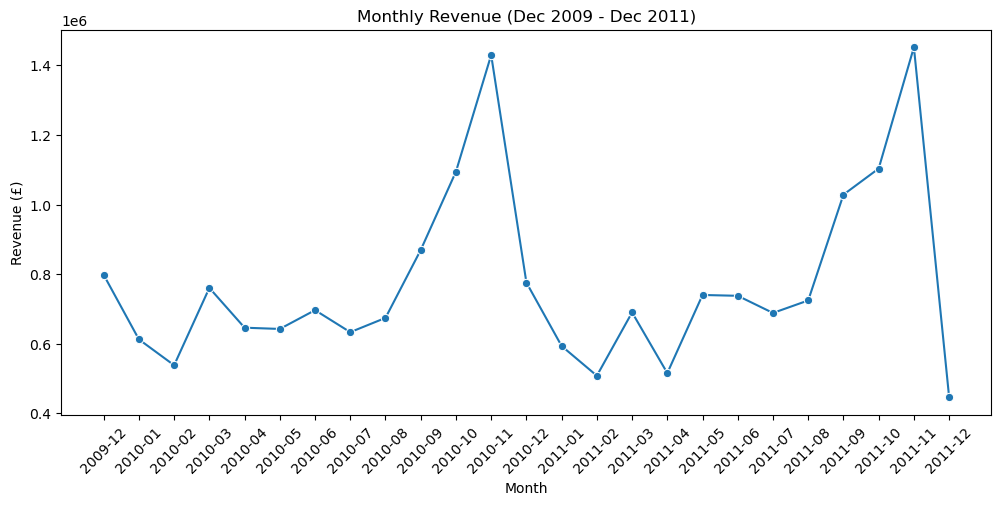

In [98]:
plt.figure(figsize=(12,5))
sns.lineplot(x=monthly_sales.index.astype(str), y=monthly_sales.values, marker='o')
plt.title('Monthly Revenue (Dec 2009 - Dec 2011)')
plt.xlabel('Month')
plt.ylabel('Revenue (£)')
plt.xticks(rotation=45)
plt.savefig('Monthly_Revenue.png')
plt.show()

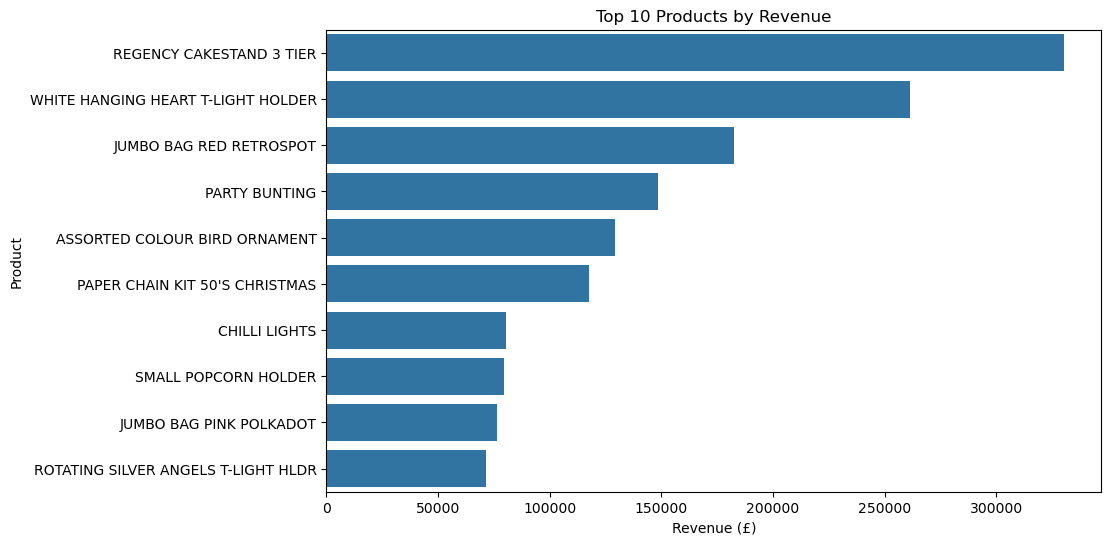

In [99]:

plt.figure(figsize=(10,6))
sns.barplot(x=top_products.values, y=top_products.index)
plt.title('Top 10 Products by Revenue')
plt.xlabel('Revenue (£)')
plt.ylabel('Product')
plt.savefig('Top_Products.png')
plt.show()

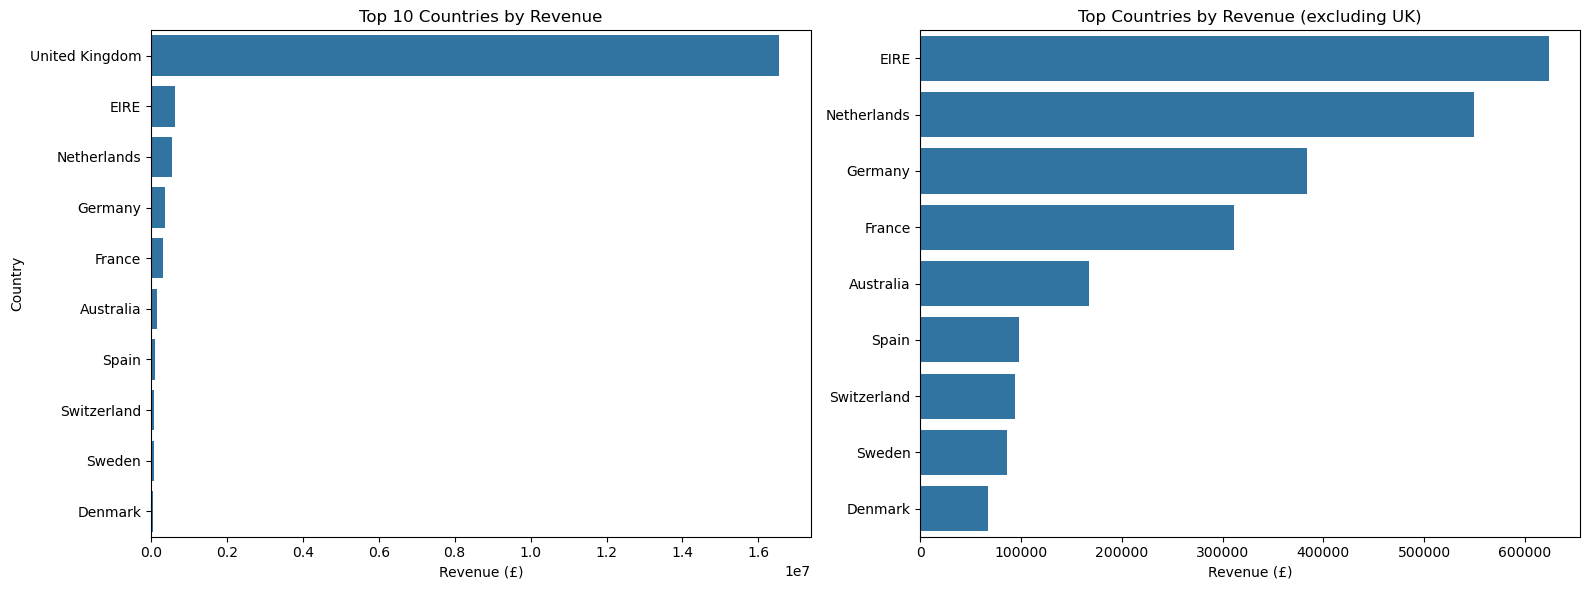

In [100]:

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16,6))

sns.barplot(x=top_countries.values, y=top_countries.index, ax=ax1)
ax1.set_title('Top 10 Countries by Revenue')
ax1.set_xlabel('Revenue (£)')
ax1.set_ylabel('Country')

top_countries_no_uk = top_countries.drop('United Kingdom')
sns.barplot(x=top_countries_no_uk.values, y=top_countries_no_uk.index, ax=ax2)
ax2.set_title('Top Countries by Revenue (excluding UK)')
ax2.set_xlabel('Revenue (£)')
ax2.set_ylabel('')

plt.tight_layout()
plt.savefig('sales_by_country.png')
plt.show()

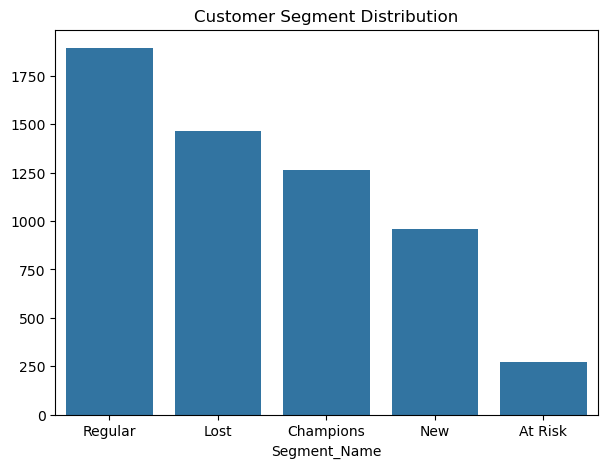

In [101]:
counts_per_segment = rfm['Segment_Name'].value_counts()

plt.figure(figsize=(7,5))
sns.barplot(x=counts_per_segment.index, y=counts_per_segment.values)
plt.title('Customer Segment Distribution')
plt.savefig('rfm_segments.png')
plt.show()

## Visuals Summary

- **Monthly Revenue Trend:** line chart showing clear seasonality, peaks in Oct-Nov each year, drops in Jan-Feb
- **Top 10 Products by Revenue:** bar chart, led by Regency Cakestand (£330K)
- **Sales by Country:** two-panel bar chart (all countries, then excluding UK) showing UK dominance and the next-tier export markets
- **Customer Segment Distribution:** bar chart of RFM segments, Regular (1,893) and Lost (1,465) are the largest groups

## Insights & Recommendations

**1. Revenue is highly seasonal**
Revenue peaks in October-November (both years), roughly double a normal month, then drops sharply in January-February.
→ **Recommendation:** plan inventory and marketing spend around the Oct-Nov peak; use Jan-Feb for clearance and customer win-back campaigns.

**2. A small group of customers drives most revenue (Pareto principle)**
23.4% of customers generate 80% of total revenue.
→ **Recommendation:** prioritize retention for this group (the "Champions" segment) with loyalty perks or early access to new products.

**3. 25% of customers are "Lost"**
1,465 customers haven't purchased recently, order rarely, and spend little.
→ **Recommendation:** run a re-engagement campaign (discount or reminder email) targeted at this segment before writing them off.

**4. 271 customers are "At Risk"**
Small group, but they used to spend well and are now going quiet.
→ **Recommendation:** highest-priority group for personal outreach — proven high value, still recoverable.

**5. Sales are UK-concentrated (~90%+ of revenue)**
Export markets (EIRE, Netherlands, Germany) are a small but real secondary base.
→ **Recommendation:** treat international markets as a growth opportunity, not the current focus.

**6. One product dominates (Regency Cakestand, £330K)**
More than 2x the next best-selling product.
→ **Recommendation:** ensure this product never goes out of stock; consider similar product lines.